In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
dataset=pd.read_csv("Mall_Customers.csv")
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
x=dataset.iloc[:,[3,4]].values

In [4]:
from sklearn.cluster import OPTICS
clusmodel=OPTICS(min_samples=7,cluster_method='xi',algorithm='ball_tree')
label=clusmodel.fit_predict(x)
label

array([-1,  4,  6,  4, -1,  4,  6, -1,  6,  4,  6, -1,  6,  4,  6,  4, -1,
        4, -1, -1, -1,  4,  6,  4,  6,  4, -1, -1, -1,  4,  6,  4,  6, -1,
       -1,  4, -1, -1, -1,  4, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1,  0,  0,  0,  0, -1,  0,  0, -1,  0, -1,  0,  0,
       -1,  0,  0, -1,  0, -1, -1,  1,  1, -1,  1, -1,  1, -1, -1, -1,  1,
       -1,  1,  1, -1,  2,  1,  3,  2,  3,  3, -1,  2,  2,  3,  2,  3,  2,
       -1, -1, -1,  3,  2,  2,  3,  2,  2, -1,  3,  2,  2,  2,  3, -1,  3,
       -1, -1, -1, -1,  8, -1,  7, -1,  8,  5,  7,  5,  7, -1,  7,  5,  8,
        5,  7,  5,  7,  5,  8, -1,  8,  5,  8, -1,  7, -1,  8,  5,  8,  5,
        7,  5,  8,  5,  7,  5,  7, -1, -1,  5,  8, -1,  8, -1,  8, -1, -1,
       -1,  8,  5,  8, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [5]:
supervised=dataset
supervised['cluster_group']=label
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster_group
0,1,Male,19,15,39,-1
1,2,Male,21,15,81,4
2,3,Female,20,16,6,6
3,4,Female,23,16,77,4
4,5,Female,31,17,40,-1
...,...,...,...,...,...,...
195,196,Female,35,120,79,-1
196,197,Female,45,126,28,-1
197,198,Male,32,126,74,-1
198,199,Male,32,137,18,-1


In [6]:
supervised.to_csv("optics_cluster.csv",index=False)
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster_group
0,1,Male,19,15,39,-1
1,2,Male,21,15,81,4
2,3,Female,20,16,6,6
3,4,Female,23,16,77,4
4,5,Female,31,17,40,-1
...,...,...,...,...,...,...
195,196,Female,35,120,79,-1
196,197,Female,45,126,28,-1
197,198,Male,32,126,74,-1
198,199,Male,32,137,18,-1


C:\Anaconda3\envs\ai\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


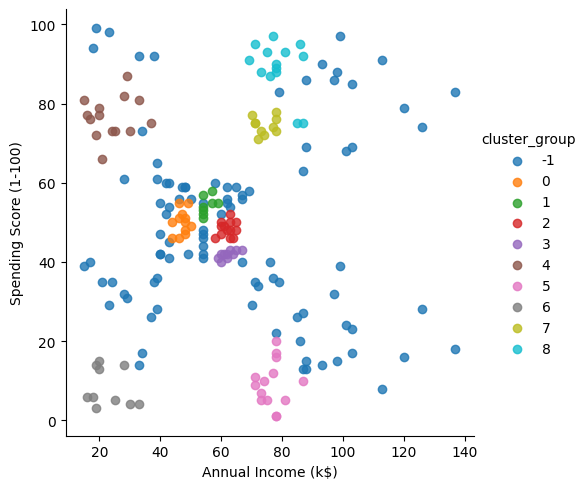

In [7]:
import seaborn as sns
facet=sns.lmplot(data=supervised,x=supervised.columns[3],y=supervised.columns[4],hue=supervised.columns[5],fit_reg=False,legend=True,legend_out=True)
facet

In [8]:
from sklearn.metrics import silhouette_score
silhouette_score(x,label)

np.float64(0.002559814973253105)